# Doppler cooling of trapped ions: an AMO tutorial

Doppler cooling is the first controlled dissipation step in most trapped-ion experiments. A red-detuned laser makes photon scattering more likely when the ion moves toward the beam, so the average radiation-pressure force opposes motion. Spontaneous emission supplies the necessary irreversibility—but also recoil heating. Their balance gives the Doppler limit.

This notebook develops that statement from the optical Bloch steady state, connects it to secular motion in a Paul trap, and turns it into experimentally useful numbers. The running example is the $4S_{1/2}\leftrightarrow4P_{1/2}$ transition of $^{40}\mathrm{Ca}^+$ near 397 nm with an 866 nm repumper. Parameters are representative rather than a substitute for the current data sheet for a particular apparatus.

## 0. AMO conventions used throughout

Keeping angular and cyclic frequencies separate prevents the most common factor-of-$2\pi$ mistake:

- $\omega_0$, $\omega_L$, $\Delta=\omega_L-\omega_0$, $\Omega$: **angular** frequencies in rad/s.
- $\Gamma$: excited-state population decay rate in s$^{-1}$; the natural intensity FWHM in Hz is $\Gamma/(2\pi)$.
- $\gamma=\Gamma/2$: optical-coherence decay rate for an isolated radiative two-level system.
- $k=2\pi/\lambda$ and photon momentum is $\hbar k$.
- $s=I/I_{\rm sat}$ is the on-resonance saturation parameter for the addressed two-level transition. With detuning, the effective saturation is reduced by the Lorentzian denominator.
- The laser detuning seen by an ion with velocity $\mathbf v$ is

$$\Delta'=\Delta-\mathbf k\cdot\mathbf v.$$

A laser is red detuned when $\Delta<0$. If the ion moves toward a counterpropagating beam, $-\mathbf k\cdot\mathbf v$ moves that beam closer to resonance.

## 1. The experimental level scheme

A useful Doppler transition is strong, nearly closed, and spectrally distinguishable from other levels. For the calcium example:

```text
             4P1/2
            /     \
  397 nm   /       \  spontaneous branch
          /         \
       4S1/2       3D3/2
                     ↑
                  866 nm repump
```

The cooling laser repeatedly excites $S_{1/2}\to P_{1/2}$. Most decays return to $S_{1/2}$, but population that leaks into metastable $D_{3/2}$ becomes dark to 397 nm unless the 866 nm repumper returns it through $P_{1/2}$. Real ions also have Zeeman sublevels. Polarization, magnetic-field direction, repump parameters, and coherent dark states therefore matter even when the two-level formula gives the correct first intuition.

In a trap, a single cooling beam can cool because the restoring force makes the ion reverse velocity every half secular period. Its mean radiation pressure merely displaces the equilibrium. For cooling all three motional modes, however, the beam wavevector must have a nonzero projection on every mode eigenvector—or multiple beams must supply the missing projections.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import hbar, k as k_B, physical_constants, pi

# Publication-style defaults. Arial is available on this system; the other
# entries provide portable fallbacks when the notebook is moved elsewhere.
COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "sky": "#56B4E9",
    "gray": "#5B5B5B",
    "black": "#202020",
}

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 16,
    "mathtext.fontset": "stixsans",
    "mathtext.default": "regular",
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 16,
    "axes.linewidth": 1.2,
    "axes.edgecolor": COLORS["black"],
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#C9C9C9",
    "grid.alpha": 0.35,
    "grid.linewidth": 0.8,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "xtick.color": COLORS["black"],
    "ytick.color": COLORS["black"],
    "legend.fontsize": 16,
    "legend.frameon": False,
    "lines.linewidth": 2.4,
    "lines.markersize": 7,
    "figure.figsize": (8.5, 5.5),
    "figure.dpi": 140,
    "figure.facecolor": "white",
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
})

def polish_axes(axes, panel_labels=True):
    """Apply consistent journal-style axis details to one or more axes."""
    axes = np.atleast_1d(axes).ravel()
    for index, axis in enumerate(axes):
        axis.spines["top"].set_visible(False)
        axis.spines["right"].set_visible(False)
        axis.tick_params(which="major", direction="out", length=6, width=1.2,
                         bottom=True, left=True, top=False, right=False)
        axis.tick_params(which="minor", direction="out", length=3.5, width=1.0,
                         bottom=True, left=True, top=False, right=False)
        axis.minorticks_on()
        if panel_labels and len(axes) > 1:
            axis.text(-0.14, 1.06, f"({chr(97 + index)})", transform=axis.transAxes,
                      fontsize=16, fontweight="bold", va="top", ha="left")
    return axes

u = physical_constants["atomic mass constant"][0]

# Representative 40Ca+ 397 nm cooling-transition parameters.
mass = 40*u
wavelength = 397e-9
k_wave = 2*pi/wavelength
linewidth_hz = 21.6e6          # Gamma/(2*pi)
Gamma = 2*pi*linewidth_hz      # population decay rate, s^-1
recoil_energy = (hbar*k_wave)**2/(2*mass)
recoil_frequency = recoil_energy/(2*pi*hbar)
recoil_temperature = recoil_energy/k_B
T_D = hbar*Gamma/(2*k_B)

print(f"Natural FWHM Gamma/(2pi) = {linewidth_hz/1e6:.1f} MHz")
print(f"Excited-state lifetime 1/Gamma = {1/Gamma*1e9:.2f} ns")
print(f"One-photon recoil velocity = {hbar*k_wave/mass:.3f} m/s")
print(f"Recoil frequency E_r/h = {recoil_frequency/1e3:.1f} kHz")
print(f"Recoil temperature E_r/kB = {recoil_temperature*1e6:.2f} microkelvin")
print(f"Two-level Doppler limit = {T_D*1e3:.3f} mK")

Natural FWHM Gamma/(2pi) = 21.6 MHz
Excited-state lifetime 1/Gamma = 7.37 ns
One-photon recoil velocity = 0.025 m/s
Recoil frequency E_r/h = 31.6 kHz
Recoil temperature E_r/kB = 1.52 microkelvin
Two-level Doppler limit = 0.518 mK


## 2. Scattering rate from the optical Bloch equations

For a stationary, closed two-level atom in steady state, the excited-state population and photon-scattering rate are

$$\rho_{ee}=\frac{s/2}{1+s+(2\Delta/\Gamma)^2},\qquad
R_{\rm sc}=\Gamma\rho_{ee}=\frac{\Gamma}{2}\frac{s}{1+s+(2\Delta/\Gamma)^2}.$$

Three pieces of AMO physics are visible:

1. At low intensity, $R_{\rm sc}\propto I$.
2. At high intensity, $\rho_{ee}\to1/2$ and $R_{\rm sc}\to\Gamma/2$.
3. Power broadening changes the angular-frequency FWHM from $\Gamma$ to $\Gamma\sqrt{1+s}$.

For a moving ion, replace $\Delta$ by $\Delta-\mathbf k\cdot\mathbf v$. Doppler cooling is therefore velocity-selective resonance fluorescence.

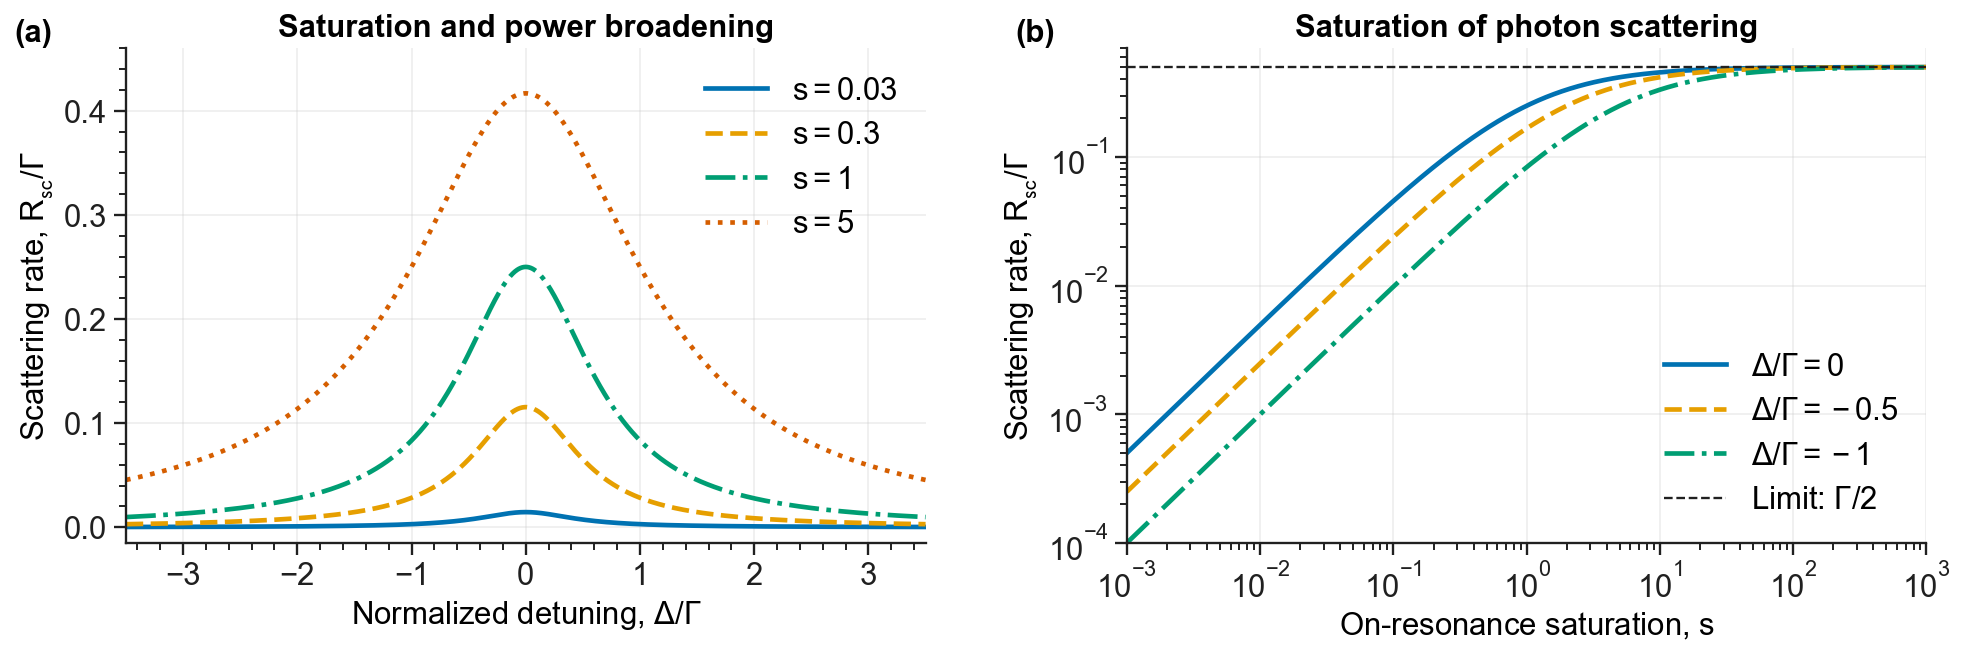

In [2]:
def scattering_rate(detuning, saturation, gamma=Gamma):
    """Two-level steady-state scattering rate; detuning and gamma are angular."""
    return (gamma/2) * saturation / (1 + saturation + (2*detuning/gamma)**2)

detuning_units = np.linspace(-3.5, 3.5, 1401)  # Delta/Gamma
s_values = [0.03, 0.3, 1.0, 5.0]
curve_colors = [COLORS["blue"], COLORS["orange"], COLORS["green"], COLORS["red"]]
curve_styles = ["-", "--", "-.", ":"]

fig, ax = plt.subplots(1, 2, figsize=(14.5, 5.2))
for s_value, color, linestyle in zip(s_values, curve_colors, curve_styles):
    rate = scattering_rate(detuning_units*Gamma, s_value)
    ax[0].plot(detuning_units, rate/Gamma, color=color, ls=linestyle,
               label=fr"$s={s_value:g}$")
ax[0].set(
    xlabel=r"Normalized detuning, $\Delta/\Gamma$",
    ylabel=r"Scattering rate, $R_{\mathrm{sc}}/\Gamma$",
    title="Saturation and power broadening",
    xlim=(-3.5, 3.5), ylim=(-0.015, 0.46),
)
ax[0].legend(loc="upper right")

s_scan = np.logspace(-3, 3, 600)
detuning_scan = [0, -0.5, -1.0]
for d_over_g, color, linestyle in zip(detuning_scan, curve_colors, curve_styles):
    ax[1].loglog(s_scan, scattering_rate(d_over_g*Gamma, s_scan)/Gamma,
                 color=color, ls=linestyle, label=fr"$\Delta/\Gamma={d_over_g:g}$")
ax[1].axhline(0.5, color=COLORS["black"], lw=1.2, ls="--", label=r"Limit: $\Gamma/2$")
ax[1].set(
    xlabel=r"On-resonance saturation, $s$",
    ylabel=r"Scattering rate, $R_{\mathrm{sc}}/\Gamma$",
    title="Saturation of photon scattering",
    xlim=(1e-3, 1e3), ylim=(1e-4, 0.7),
)
ax[1].legend(loc="lower right")
polish_axes(ax)
fig.tight_layout(pad=1.6, w_pad=2.5)
plt.show()

## 3. Radiation pressure becomes viscous damping

Absorption from a traveling wave gives a directed momentum kick $+\hbar\mathbf k$; spontaneous emission averages to zero directed momentum in free space but contributes momentum variance. For one beam,

$$\mathbf F(\mathbf v)=\hbar\mathbf k\,R_{\rm sc}(\Delta-\mathbf k\cdot\mathbf v).$$

The cleanest derivation uses two equal counterpropagating beams in 1D:

$$F(v)=\hbar k\left[R_{\rm sc}(\Delta-kv)-R_{\rm sc}(\Delta+kv)\right].$$

At small velocity, $F\simeq-\alpha v$. Differentiating the Lorentzian gives

$$\alpha=-\frac{8\hbar k^2s(\Delta/\Gamma)}{\left[1+s+(2\Delta/\Gamma)^2\right]^2}.$$

For red detuning, $\Delta<0$ and therefore $\alpha>0$: kinetic energy is removed. For blue detuning, the same force is anti-damping. The linear approximation is local; capture requires the Doppler shift to bring at least one beam near the power-broadened line.

For one beam projected onto a trapped normal mode, the velocity-dependent damping coefficient is half the two-beam result times $(\hat{\mathbf k}\cdot\hat{\mathbf e}_m)^2$. The constant radiation pressure shifts the mode's equilibrium but does not by itself heat a perfectly harmonic, static trap.

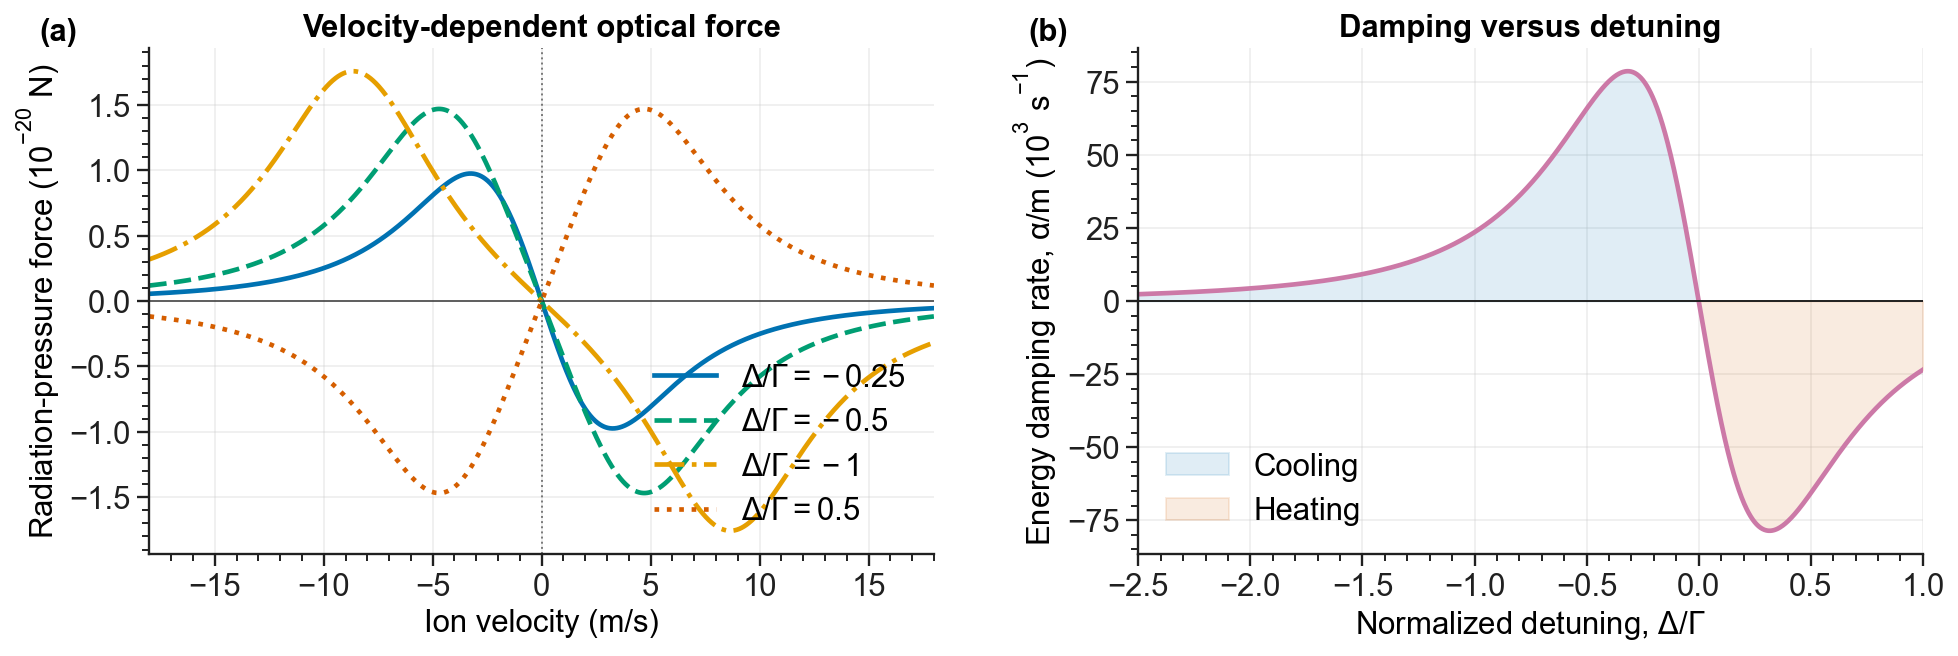

At Delta=-Gamma/2 and s=0.2, alpha/m = 65.7 x 10^3 s^-1 (two-beam model).
Velocity for |kv|=Gamma: 8.58 m/s
Corresponding one-dimensional kinetic energy: 0.177 K


In [3]:
def molasses_force(velocity, detuning, saturation):
    return hbar*k_wave * (
        scattering_rate(detuning-k_wave*velocity, saturation)
        - scattering_rate(detuning+k_wave*velocity, saturation)
    )

def friction_two_beam(detuning, saturation):
    denominator = (1 + saturation + (2*detuning/Gamma)**2)**2
    return -8*hbar*k_wave**2*saturation*(detuning/Gamma)/denominator

s_cool = 0.20
velocity = np.linspace(-18, 18, 1601)
detunings = [-0.25, -0.5, -1.0, +0.5]
force_colors = [COLORS["blue"], COLORS["green"], COLORS["orange"], COLORS["red"]]
force_styles = ["-", "--", "-.", ":"]

fig, ax = plt.subplots(1, 2, figsize=(14.5, 5.2))
for d_over_g, color, linestyle in zip(detunings, force_colors, force_styles):
    force = molasses_force(velocity, d_over_g*Gamma, s_cool)
    ax[0].plot(velocity, force/1e-20, color=color, ls=linestyle,
               label=fr"$\Delta/\Gamma={d_over_g:g}$")
ax[0].axhline(0, color=COLORS["black"], lw=1.0, alpha=0.7)
ax[0].axvline(0, color=COLORS["gray"], lw=1.0, ls=":", alpha=0.8)
ax[0].set(
    xlabel="Ion velocity (m/s)", ylabel=r"Radiation-pressure force ($10^{-20}$ N)",
    title="Velocity-dependent optical force", xlim=(-18, 18),
)
ax[0].legend(loc="lower right")

d_scan = np.linspace(-2.5, 1.0, 1200)
alpha_scan = friction_two_beam(d_scan*Gamma, s_cool)
ax[1].plot(d_scan, alpha_scan/mass/1e3, color=COLORS["purple"])
ax[1].fill_between(d_scan, 0, alpha_scan/mass/1e3,
                   where=alpha_scan >= 0, color=COLORS["blue"], alpha=0.12,
                   label="Cooling")
ax[1].fill_between(d_scan, 0, alpha_scan/mass/1e3,
                   where=alpha_scan < 0, color=COLORS["red"], alpha=0.12,
                   label="Heating")
ax[1].axhline(0, color=COLORS["black"], lw=1.0)
ax[1].set(
    xlabel=r"Normalized detuning, $\Delta/\Gamma$",
    ylabel=r"Energy damping rate, $\alpha/m$ ($10^3$ s$^{-1}$)",
    title="Damping versus detuning", xlim=(-2.5, 1.0),
)
ax[1].legend(loc="lower left")
polish_axes(ax)
fig.tight_layout(pad=1.6, w_pad=2.5)
plt.show()

alpha_example = friction_two_beam(-Gamma/2, s_cool)
capture_velocity = Gamma/k_wave
capture_energy_K = 0.5*mass*capture_velocity**2/k_B
print(f"At Delta=-Gamma/2 and s={s_cool}, alpha/m = {alpha_example/mass/1e3:.1f} x 10^3 s^-1 (two-beam model).")
print(f"Velocity for |kv|=Gamma: {capture_velocity:.2f} m/s")
print(f"Corresponding one-dimensional kinetic energy: {capture_energy_K:.3f} K")

## 4. Why cooling stops: recoil diffusion and the Doppler limit

Each scattering event contains a directed absorption kick and a random spontaneous-emission kick. The mean force damps motion, but the kick variance causes momentum diffusion. In the semiclassical limit ($k_BT\gg E_r$), balancing diffusion against friction gives the standard two-level Doppler result

$$T(\Delta,s)=\frac{\hbar\Gamma}{2k_B}
\frac{1+s+(2\Delta/\Gamma)^2}{-4\Delta/\Gamma},\qquad \Delta<0.$$

Minimizing with respect to detuning gives

$$\Delta_{\rm opt}=-\frac{\Gamma}{2}\sqrt{1+s},\qquad
T_{\min}=T_D\sqrt{1+s},\qquad T_D=\frac{\hbar\Gamma}{2k_B}.$$

Thus $\Delta=-\Gamma/2$ and $T_D$ are the low-saturation limits. More intensity increases the scattering and often shortens initial cooling, but power broadening raises the asymptotic temperature. Real trapped-ion temperatures may be higher because of micromotion, laser-frequency/intensity noise, recoil geometry, dark states, background-gas collisions, electric-field noise, and imperfect mode projection. Multilevel structure can also produce sub- or super-Doppler behavior, so this is a benchmark—not a universal thermometer.

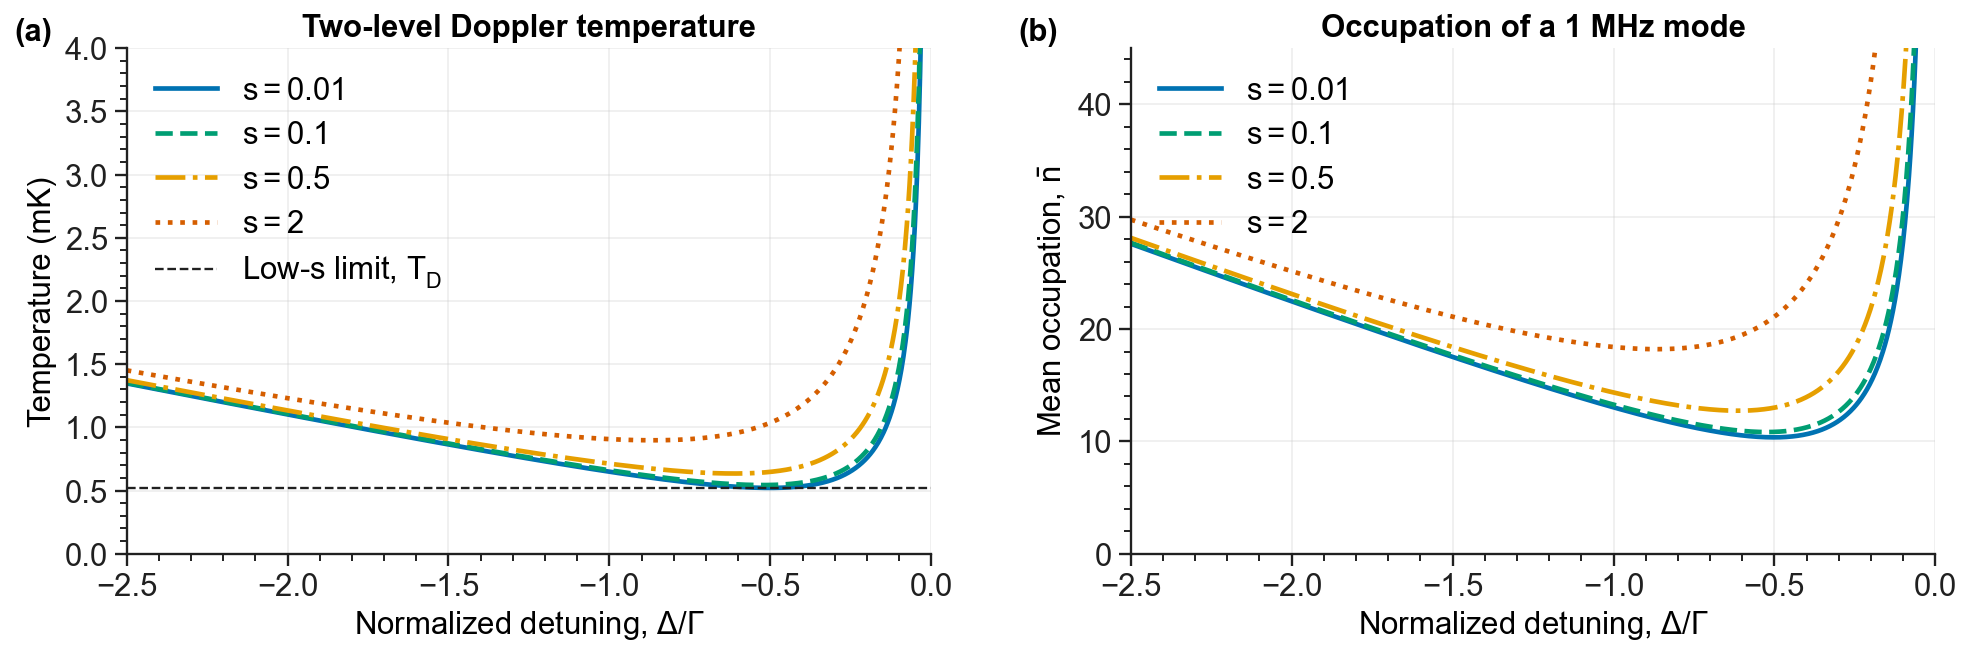

For s=0.1, optimum Delta/(2pi) = -11.33 MHz
Minimum two-level temperature = 0.544 mK
At 1 MHz: exact nbar=10.83, high-T estimate=10.83
Doppler cooling localizes the ion, but normally does not prepare n=0.


In [4]:
def doppler_temperature(detuning, saturation):
    x = np.asarray(detuning)/Gamma
    result = np.full_like(x, np.nan, dtype=float)
    red = x < 0
    result[red] = (hbar*Gamma/(2*k_B)) * (
        (1+saturation+(2*x[red])**2)/(-4*x[red])
    )
    return result

d_red = np.linspace(-2.5, -0.02, 1200)*Gamma
trap_frequency_hz = 1.0e6
omega_trap = 2*pi*trap_frequency_hz
saturation_values = [0.01, 0.1, 0.5, 2.0]
curve_colors = [COLORS["blue"], COLORS["green"], COLORS["orange"], COLORS["red"]]
curve_styles = ["-", "--", "-.", ":"]

fig, ax = plt.subplots(1, 2, figsize=(14.5, 5.2))
for s_value, color, linestyle in zip(saturation_values, curve_colors, curve_styles):
    temperature = doppler_temperature(d_red, s_value)
    ax[0].plot(d_red/Gamma, temperature*1e3, color=color, ls=linestyle,
               label=fr"$s={s_value:g}$")
    nbar = 1/(np.exp(hbar*omega_trap/(k_B*temperature))-1)
    ax[1].plot(d_red/Gamma, nbar, color=color, ls=linestyle,
               label=fr"$s={s_value:g}$")
ax[0].axhline(T_D*1e3, color=COLORS["black"], ls="--", lw=1.2,
              label=r"Low-$s$ limit, $T_D$")
ax[0].set(
    xlabel=r"Normalized detuning, $\Delta/\Gamma$", ylabel="Temperature (mK)",
    title="Two-level Doppler temperature", xlim=(-2.5, 0), ylim=(0, 4),
)
ax[0].legend(loc="upper left")
ax[1].set(
    xlabel=r"Normalized detuning, $\Delta/\Gamma$",
    ylabel=r"Mean occupation, $\bar{n}$",
    title="Occupation of a 1 MHz mode", xlim=(-2.5, 0), ylim=(0, 45),
)
ax[1].legend(loc="upper left")
polish_axes(ax)
fig.tight_layout(pad=1.6, w_pad=2.5)
plt.show()

s_example = 0.1
delta_opt = -0.5*Gamma*np.sqrt(1+s_example)
T_opt = doppler_temperature(np.array([delta_opt]), s_example)[0]
nbar_exact = 1/(np.exp(hbar*omega_trap/(k_B*T_opt))-1)
nbar_classical = k_B*T_opt/(hbar*omega_trap)-0.5
print(f"For s={s_example}, optimum Delta/(2pi) = {delta_opt/(2*pi)/1e6:.2f} MHz")
print(f"Minimum two-level temperature = {T_opt*1e3:.3f} mK")
print(f"At 1 MHz: exact nbar={nbar_exact:.2f}, high-T estimate={nbar_classical:.2f}")
print("Doppler cooling localizes the ion, but normally does not prepare n=0.")

## 5. Secular motion, mode geometry, and micromotion

For one harmonic secular mode,

$$H_m=\frac{p_m^2}{2m}+\frac12m\omega_m^2x_m^2.$$

If the velocity-dependent force is $F_m=-\alpha_m\dot x_m$, the cycle-averaged energy obeys

$$\frac{d\langle E_m\rangle}{dt}=-\frac{\alpha_m}{m}\left(\langle E_m\rangle-E_{m,\infty}\right),$$

so the energy time constant is $\tau_E=m/\alpha_m$. For a single beam, $\alpha_m\propto(\hat{\mathbf k}\cdot\hat{\mathbf e}_m)^2$. A mode orthogonal to every cooling beam is dark to first order, although anharmonicity and Coulomb coupling in an ion crystal can redistribute energy.

In an RF Paul trap the position contains slow secular motion plus micromotion at the RF drive frequency. **Intrinsic micromotion** is required by the Mathieu dynamics; **excess micromotion** arises when stray DC fields push the ion away from the RF null or when RF phases are imbalanced. Micromotion produces a time-dependent Doppler shift and RF sidebands, broadens the effective cooling resonance, raises scattering diffusion, and can make the observed optimum detuning more negative. Doppler cooling does not compensate excess micromotion; compensate the fields and RF phase at the trap.

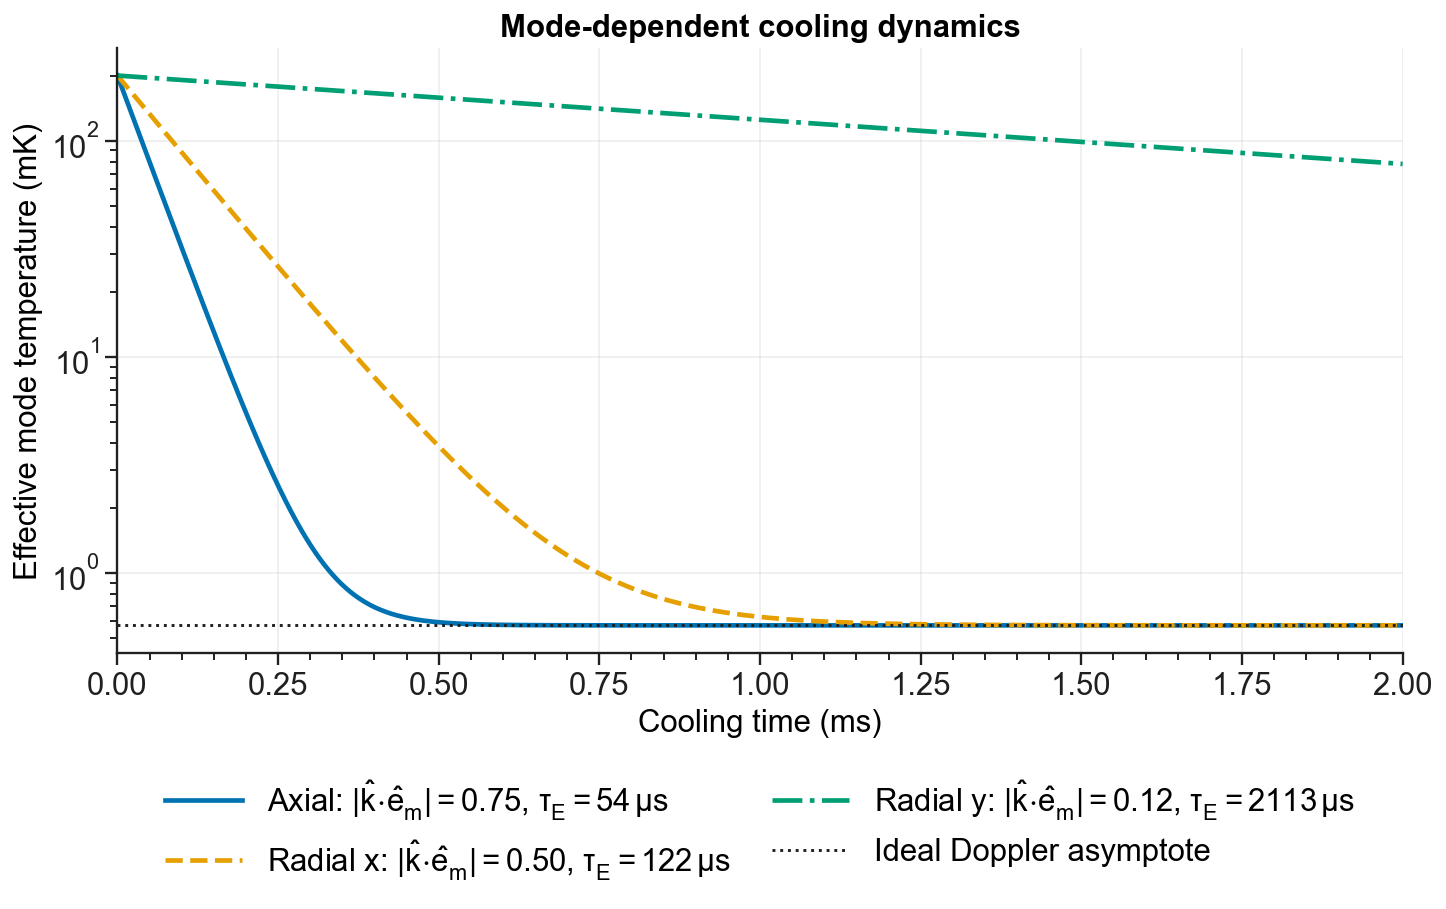

Axial   : projection=0.75, tau_E=   54.1 us, ideal nbar= 14.4
Radial x: projection=0.50, tau_E=  121.7 us, ideal nbar= 11.4
Radial y: projection=0.12, tau_E= 2112.9 us, ideal nbar=  8.6


In [5]:
# Mode-by-mode cooling envelope for one beam in a harmonic trap.
# One-beam alpha is half the two-beam coefficient, times the squared projection.
mode_frequencies = np.array([0.8e6, 1.0e6, 1.3e6])
mode_names = ["Axial", "Radial x", "Radial y"]
projections = np.array([0.75, 0.50, 0.12])
alpha_single_base = alpha_example/2
alpha_modes = alpha_single_base*projections**2
tau_energy = mass/alpha_modes

time = np.linspace(0, 2e-3, 1200)
T_initial = 0.20               # K, illustrative post-loading energy scale
T_final = doppler_temperature(np.array([-Gamma/2]), s_cool)[0]
mode_colors = [COLORS["blue"], COLORS["orange"], COLORS["green"]]
mode_styles = ["-", "--", "-."]

fig, ax = plt.subplots(figsize=(10.8, 7.2))
for name, projection, tau, color, linestyle in zip(
        mode_names, projections, tau_energy, mode_colors, mode_styles):
    temperature = T_final + (T_initial-T_final)*np.exp(-time/tau)
    ax.semilogy(time*1e3, temperature*1e3, color=color, ls=linestyle,
                label=fr"{name}: $|\hat{{k}}\!\cdot\!\hat{{e}}_m|={projection:.2f}$, "
                      fr"$\tau_E={tau*1e6:.0f}\,\mu$s")
ax.axhline(T_final*1e3, color=COLORS["black"], ls=":", lw=1.5,
           label="Ideal Doppler asymptote")
ax.set(
    xlabel="Cooling time (ms)", ylabel="Effective mode temperature (mK)",
    title="Mode-dependent cooling dynamics", xlim=(0, 2.0),
)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2,
          columnspacing=1.3, handlelength=2.5)
polish_axes(ax, panel_labels=False)
fig.subplots_adjust(left=0.13, right=0.98, top=0.91, bottom=0.31)
plt.show()

for name, freq, projection, tau in zip(mode_names, mode_frequencies, projections, tau_energy):
    nbar_final = 1/(np.exp(hbar*2*pi*freq/(k_B*T_final))-1)
    print(f"{name:8s}: projection={projection:.2f}, tau_E={tau*1e6:7.1f} us, ideal nbar={nbar_final:5.1f}")

## 6. The repumper and multilevel reality

The two-level scattering rate silently assumes every decay returns to the cooling ground state. If a fraction $b_D$ decays to a metastable state, the probability of surviving $N$ cooling scatters without shelving is roughly $(1-b_D)^N$. Even a few-percent leak therefore stops fluorescence quickly.

An incoherent three-level rate model is useful for intuition. Let $W_c$ and $W_r$ be stimulated absorption/emission rates on cooling and repump legs. With populations $P_S,P_D,P_P$,

$$\dot P_S=-W_cP_S+(W_c+b_S\Gamma)P_P,$$
$$\dot P_D=-W_rP_D+(W_r+b_D\Gamma)P_P,$$
$$P_S+P_D+P_P=1.$$

The fluorescence rate is $\Gamma P_P$. A weak repumper bottlenecks the cycle; an extremely strong repumper can power broaden levels and, in a coherent treatment, alter dark resonances. The simple rate model below deliberately omits Zeeman coherences and is not a replacement for multilevel optical Bloch equations.

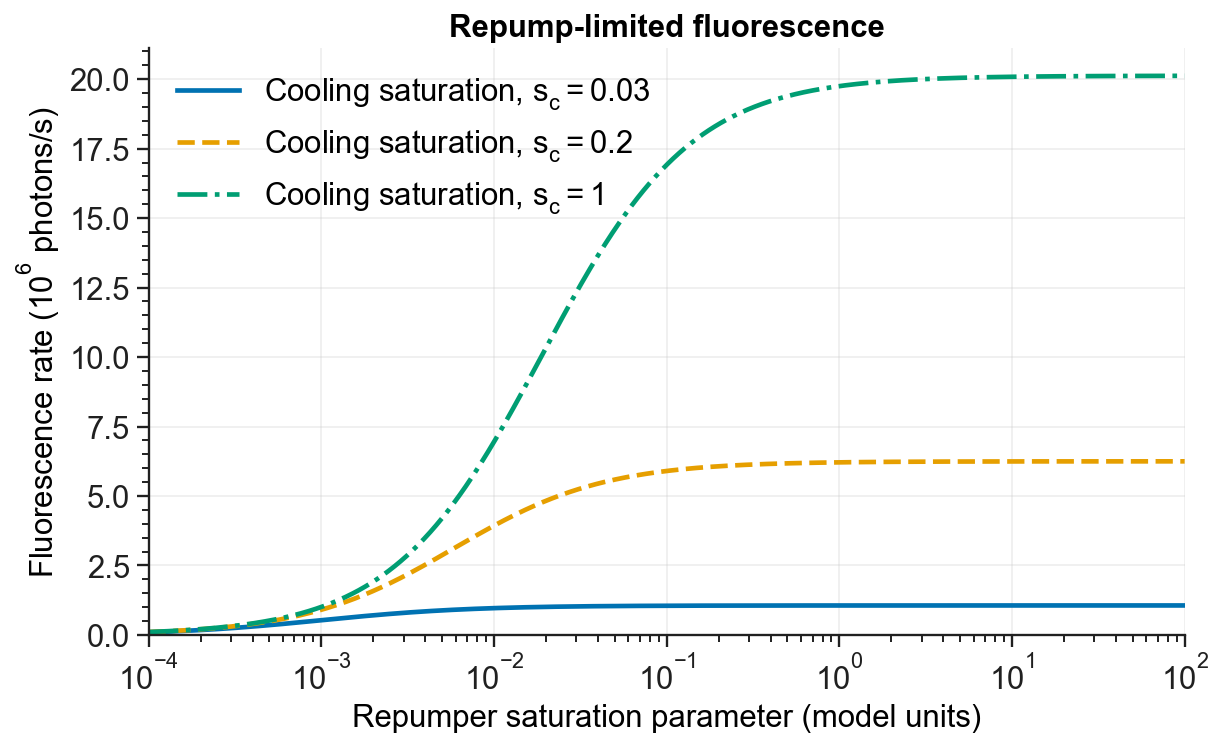

With no repumper, population accumulates in D and steady fluorescence vanishes.
In the lab, optimize repump detuning, intensity, polarization, and magnetic field together.


In [6]:
def stimulated_rate(saturation, detuning, gamma=Gamma):
    """Rate W such that a closed two-level model gives the usual rho_ee."""
    return (gamma/2)*saturation/(1+(2*detuning/gamma)**2)

def three_level_steady_scattering(s_c, delta_c, s_r, delta_r, b_D=0.064):
    Wc = stimulated_rate(s_c, delta_c)
    Wr = stimulated_rate(np.asarray(s_r), delta_r)
    b_S = 1-b_D
    # From steady-state balance: Ps/Pp=(Wc+bS*Gamma)/Wc, similarly for D.
    Pp = 1/(1 + (Wc+b_S*Gamma)/Wc + (Wr+b_D*Gamma)/Wr)
    return Gamma*Pp

repump_s = np.logspace(-4, 2, 700)
cooling_s_values = [0.03, 0.2, 1.0]
repump_colors = [COLORS["blue"], COLORS["orange"], COLORS["green"]]
repump_styles = ["-", "--", "-."]

fig, ax = plt.subplots(figsize=(9.2, 5.8))
for cooling_s, color, linestyle in zip(cooling_s_values, repump_colors, repump_styles):
    fluorescence = three_level_steady_scattering(
        cooling_s, -Gamma/2, repump_s, 0.0
    )
    ax.semilogx(repump_s, fluorescence/1e6, color=color, ls=linestyle,
                label=fr"Cooling saturation, $s_c={cooling_s:g}$")
ax.set(
    xlabel="Repumper saturation parameter (model units)",
    ylabel=r"Fluorescence rate ($10^6$ photons/s)",
    title="Repump-limited fluorescence",
    xlim=(1e-4, 1e2), ylim=(0, None),
)
ax.legend(loc="upper left")
polish_axes(ax, panel_labels=False)
fig.tight_layout(pad=1.5)
plt.show()

print("With no repumper, population accumulates in D and steady fluorescence vanishes.")
print("In the lab, optimize repump detuning, intensity, polarization, and magnetic field together.")

## 7. From a hot ion to a cold bright ion

A practical sequence often looks like this:

1. **Provide a quantization field.** It separates Zeeman components and defines polarization. Avoid accidental dark states while keeping field noise compatible with later spectroscopy.
2. **Turn on every return path.** Cooling, repump, and any required deshelving lasers must overlap the ion spatially and spectrally.
3. **Acquire hot ions broadly.** Newly loaded or collision-heated ions can have Doppler shifts beyond the narrow capture range. Use higher power, a more negative detuning, a frequency sweep/chirp, or a short broad-spectrum stage.
4. **Compress toward the Doppler optimum.** After capture, reduce intensity and move detuning toward roughly $-\Gamma/2$ (modified by saturation and multilevel physics).
5. **Check all mode projections.** A bright ion can still have a hot weakly projected mode. Beam geometry is part of the cooling Hamiltonian.
6. **Compensate micromotion.** Use RF-photon correlation, resolved micromotion sidebands, or imaging/position methods; iterate DC compensation and RF phase balance.
7. **Measure, do not infer.** Calibrate fluorescence, perform Doppler-recooling or release-and-recapture measurements when appropriate, and use red/blue motional sideband asymmetry after entering the resolved-sideband regime.

Fluorescence is both the cooling channel and a diagnostic. A suddenly heated ion can initially scatter less because its instantaneous Doppler shift carries it away from resonance; fluorescence rises as its secular energy falls. This is the basis of Doppler-recooling thermometry, but quantitative inference requires the actual multilevel scattering model, laser geometry, and energy distribution.

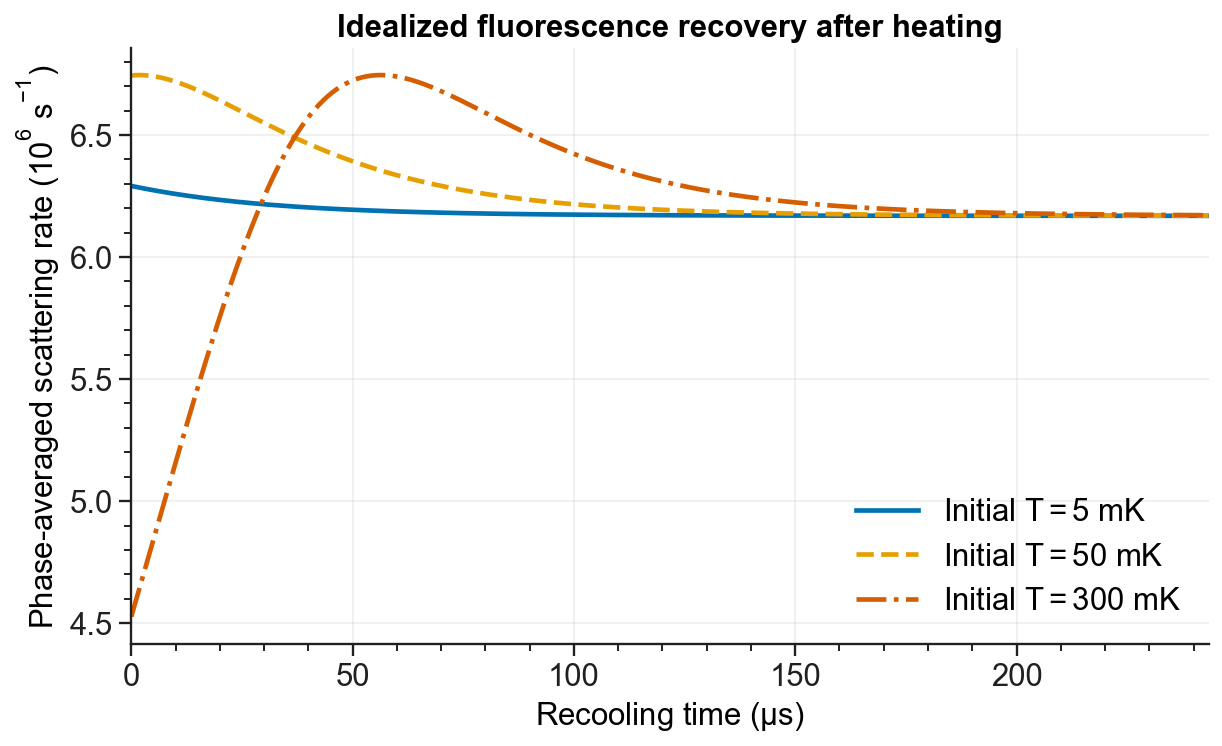

Idealized one-beam energy damping time (unit projection): 30.4 us
The plotted trace neglects diffusion, recoil geometry, trap anharmonicity, and multilevel dynamics.


In [7]:
# A simple phase-averaged fluorescence recooling picture.
# The velocity amplitude decays as exp[-t/(2*tau_E)] while energy decays as exp[-t/tau_E].
phase = np.linspace(0, 2*pi, 1000, endpoint=False)
tau_demo = mass/(alpha_example/2)  # one beam with unit projection
time_recool = np.linspace(0, 8*tau_demo, 500)
initial_temperatures = [5e-3, 50e-3, 0.30]
recooling_colors = [COLORS["blue"], COLORS["orange"], COLORS["red"]]
recooling_styles = ["-", "--", "-."]

fig, ax = plt.subplots(figsize=(9.2, 5.8))
for T0, color, linestyle in zip(initial_temperatures, recooling_colors, recooling_styles):
    # In 1D harmonic motion, total energy k_B*T0 gives v_max=sqrt(2*kBT0/m).
    v_amp0 = np.sqrt(2*k_B*T0/mass)
    v_amp = v_amp0*np.exp(-time_recool/(2*tau_demo))
    velocities = v_amp[:, None]*np.cos(phase)[None, :]
    rates = scattering_rate(-Gamma/2-k_wave*velocities, s_cool)
    mean_rate = np.mean(rates, axis=1)
    ax.plot(time_recool*1e6, mean_rate/1e6, color=color, ls=linestyle,
            label=fr"Initial $T={T0*1e3:g}$ mK")
ax.set(
    xlabel=r"Recooling time ($\mu$s)",
    ylabel=r"Phase-averaged scattering rate ($10^6$ s$^{-1}$)",
    title="Idealized fluorescence recovery after heating",
    xlim=(0, time_recool[-1]*1e6),
)
ax.legend(loc="lower right")
polish_axes(ax, panel_labels=False)
fig.tight_layout(pad=1.5)
plt.show()

print(f"Idealized one-beam energy damping time (unit projection): {tau_demo*1e6:.1f} us")
print("The plotted trace neglects diffusion, recoil geometry, trap anharmonicity, and multilevel dynamics.")

## 8. Doppler cooling versus ground-state cooling

The Lamb–Dicke parameter for mode $m$ is

$$\eta_m=|\mathbf k\cdot\hat{\mathbf e}_m|x_{0,m},\qquad
x_{0,m}=\sqrt{\frac{\hbar}{2m\omega_m}}.$$

At the Doppler limit, a 1 MHz calcium mode still has $\bar n\sim10$. Doppler cooling is nevertheless transformative: it localizes the ion to a small fraction of the optical wavelength, narrows the velocity distribution, and supplies a reliable starting state for optical pumping and resolved-sideband cooling.

The regimes should not be conflated:

| Regime | Spectral condition | Main mechanism | Typical outcome |
|---|---|---|---|
| Doppler cooling | broad transition, often $\Gamma\gg\omega_m$ | velocity-dependent radiation pressure | mK, many motional quanta |
| Resolved-sideband cooling | addressed linewidth $\ll\omega_m$ | drive red sideband and optically pump | $\bar n<1$ possible |
| EIT cooling | coherent multilevel dark/bright resonances | engineered absorption spectrum | cool multiple modes efficiently |
| Sympathetic cooling | Coulomb-coupled coolant species/ion | remove energy through another ion | protects spectroscopy/qubit species |

Sideband thermometry uses the red/blue sideband ratio in the Lamb–Dicke thermal regime: $P_{\rm red}/P_{\rm blue}=\bar n/(\bar n+1)$. It becomes most useful after the system is already near the quantum regime; ordinary Doppler fluorescence is generally not a direct measurement of $\bar n$.

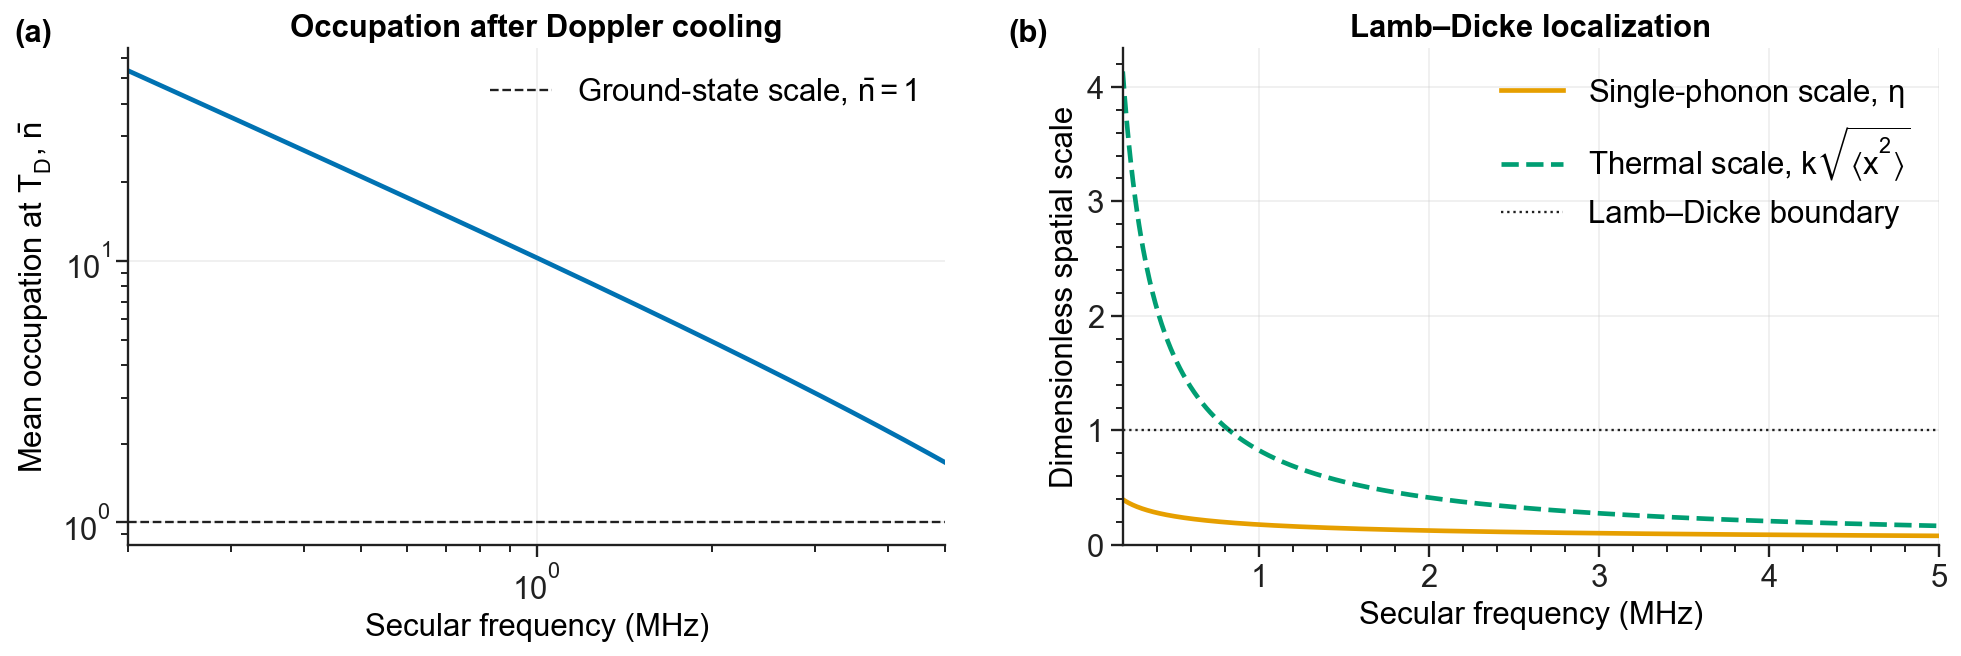

0.5 MHz: eta=0.252, nbar_D=21.1, eta*sqrt(2n+1)=1.65
1.0 MHz: eta=0.178, nbar_D=10.3, eta*sqrt(2n+1)=0.83
3.0 MHz: eta=0.103, nbar_D=3.1, eta*sqrt(2n+1)=0.28


In [8]:
# Quantum scales versus secular frequency.
secular_frequencies = np.linspace(0.2e6, 5e6, 800)
omega_modes = 2*pi*secular_frequencies
x0_modes = np.sqrt(hbar/(2*mass*omega_modes))
eta_modes = k_wave*x0_modes
nbar_D = 1/(np.exp(hbar*omega_modes/(k_B*T_D))-1)
ld_variance = eta_modes**2*(2*nbar_D+1)  # k^2 <x^2> for a thermal state

fig, ax = plt.subplots(1, 2, figsize=(14.5, 5.2))
ax[0].loglog(secular_frequencies/1e6, nbar_D, color=COLORS["blue"])
ax[0].axhline(1, color=COLORS["black"], ls="--", lw=1.2,
              label=r"Ground-state scale, $\bar{n}=1$")
ax[0].set(
    xlabel="Secular frequency (MHz)", ylabel=r"Mean occupation at $T_D$, $\bar{n}$",
    title="Occupation after Doppler cooling", xlim=(0.2, 5.0),
)
ax[0].legend(loc="upper right")

ax[1].plot(secular_frequencies/1e6, eta_modes, color=COLORS["orange"],
           label=r"Single-phonon scale, $\eta$")
ax[1].plot(secular_frequencies/1e6, np.sqrt(ld_variance), color=COLORS["green"], ls="--",
           label=r"Thermal scale, $k\sqrt{\langle x^2\rangle}$")
ax[1].axhline(1, color=COLORS["black"], ls=":", lw=1.2,
              label="Lamb–Dicke boundary")
ax[1].set(
    xlabel="Secular frequency (MHz)", ylabel="Dimensionless spatial scale",
    title="Lamb–Dicke localization", xlim=(0.2, 5.0), ylim=(0, None),
)
ax[1].legend(loc="upper right")
polish_axes(ax)
fig.tight_layout(pad=1.6, w_pad=2.5)
plt.show()

for freq_mhz in [0.5, 1.0, 3.0]:
    om = 2*pi*freq_mhz*1e6
    eta_value = k_wave*np.sqrt(hbar/(2*mass*om))
    n_value = 1/(np.exp(hbar*om/(k_B*T_D))-1)
    print(f"{freq_mhz:3.1f} MHz: eta={eta_value:.3f}, nbar_D={n_value:.1f}, eta*sqrt(2n+1)={eta_value*np.sqrt(2*n_value+1):.2f}")

## 9. Troubleshooting by AMO symptom

| Observation | Likely interpretation | Productive checks |
|---|---|---|
| No fluorescence | ion absent, cooling/repump off resonance, population shelved, beam misses ion | scan each laser; verify wavemeter/reference; check deshelving and imaging path |
| Bright but broad/unstable spot | excess micromotion, hot weakly cooled mode, collisions, laser noise | compensate DC fields; check RF phase; inspect beam projections and laser locks |
| Fluorescence vanishes at particular detuning/B field | coherent dark resonance or optical pumping into a dark Zeeman state | change polarization, magnetic field, or repump detuning; model coherences |
| Ion cools only at very large red detuning | large micromotion or initially high energy | broaden acquisition, then compensate micromotion and reduce detuning |
| Ion is lost when cooling intensity is reduced | not yet captured, poor repumping, hot radial mode, shallow trap | stage the ramp; verify overlap and trap depth |
| High fluorescence but poor sideband spectrum | fluorescence is not a temperature measurement; one mode may be hot | check geometry, micromotion, linewidth, and sideband thermometry |
| Cooling optimum drifts | laser detuning/intensity drift, B-field drift, charging changes micromotion | log laser locks, fluorescence spectrum, compensation voltages, and RF correlation |

An experimentally useful distinction is **capture**, **cooling rate**, and **final temperature**. High intensity and broad detuning can improve capture; intermediate parameters may maximize damping; low saturation near the Doppler optimum minimizes the ideal asymptotic temperature. One setting rarely optimizes all three.

## 10. Summary and numerical exercises

The AMO picture can be compressed into five statements:

1. The optical Bloch equations provide a velocity-dependent scattering rate through $\Delta' = \Delta-\mathbf k\cdot\mathbf v$.
2. Red detuning turns that dependence into viscous damping, while spontaneous-emission recoil creates diffusion.
3. Their balance gives the two-level Doppler benchmark $T_D=\hbar\Gamma/(2k_B)$.
4. A trapped ion is not free-space molasses: secular-mode projections, radiation-pressure displacement, RF micromotion, multilevel repumping, and dark states determine the laboratory result.
5. Doppler cooling prepares the localized, bright starting point for state preparation and resolved-sideband cooling; it does not normally produce the motional ground state.

Suggested experiments with the code:

1. Change the linewidth to compare a broad dipole transition with a narrow intercombination line. Track capture velocity, $T_D$, and scattering rate.
2. Numerically differentiate the force at $v=0$ and verify the analytic $\alpha$.
3. For fixed laser power, scan detuning and compare the detuning that maximizes damping with the one that minimizes temperature.
4. Set one mode projection to zero and explain why its ideal cooling time diverges.
5. Add a sinusoidal micromotion velocity $v_{\rm mm}\cos\Omega_{\rm RF}t$ and average the scattering rate over an RF period.
6. Vary repump strength in the rate model, then list which observed features would require coherent multilevel optical Bloch equations.
7. Replace the exponential recooling ansatz with a Monte Carlo sequence of absorption and spontaneous-emission kicks in a harmonic trap.

### Further reading

- H. J. Metcalf and P. van der Straten, *Laser Cooling and Trapping*.
- D. J. Wineland and W. M. Itano, “Laser cooling of atoms,” *Physical Review A* **20**, 1521 (1979).
- D. Leibfried *et al.*, “Quantum dynamics of single trapped ions,” *Reviews of Modern Physics* **75**, 281 (2003).
- D. A. Steck, *Quantum and Atom Optics*, laser-cooling and two-level-atom chapters.

Different references distribute factors of two between $\Gamma$, the coherence HWHM, and the intensity FWHM. Translate definitions before comparing formulas.